### **Loading the data:**

##### 1) Building the functions:

In [73]:
from string import punctuation
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from os import listdir
from pickle import dump

# Load the data from the fille:
def load_data(file_name):
    file = open(file_name, 'r')
    text = file.read()
    file.close()
    return text

# Preprocessing the data & creating tokens:
def data_to_tokens(data):
    # split the text to into words
    tokens = data.split(' ')
    # remove the punctuation
    table = str.maketrans('', '', punctuation)
    tokens = [w.translate(table) for w in tokens]
    # remove the tokens that are not alphabetic
    tokens = [word for word in tokens if word.isalpha()]
    # remove the stope words
    stop_words = stopwords.words('english')
    tokens = [w for w in tokens if not w in stop_words]
    # remove the words that have length less or equal to 1
    tokens = [word for word in tokens if len(word) > 1]
    tokens = " ".join(tokens)
    return tokens


# load all the documents from the directory
def handle_documents(directory, is_train):
    documents = list()
    for file_name in listdir(directory):
        if is_train and file_name.startswith('cv9'):
            continue
        if not is_train and not file_name.startswith('cv9'):
            continue
        # load the document
        path = directory + '/' + file_name
        
        data = load_data(path)
        
        # clean the document
        tokens = data_to_tokens(data)
        
        documents.append(tokens)
    return documents

def save_data(dataset, file_name):
    dump(dataset, open(file_name, 'wb'))
    print('Saved dataset: %s' % file_name)

[nltk_data] Downloading package stopwords to /home/muh7/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##### 2) Call functions:

In [74]:
# Load the training files
neg_docs_train = handle_documents('review_polarity/txt_sentoken/neg', is_train=True)
pos_docs_train = handle_documents('review_polarity/txt_sentoken/pos', is_train=True)


# Load the testing files
neg_docs_test = handle_documents('review_polarity/txt_sentoken/neg', is_train=False)
pos_docs_test = handle_documents('review_polarity/txt_sentoken/pos', is_train=False)

In [75]:
# train
train_x = neg_docs_train + pos_docs_train
train_y = [0 for _ in range(900)] + [1 for _ in range(900)]

save_data([train_x,train_y], 'review_polarity/txt_sentoken/train_x.pkl')

# test
test_x = neg_docs_test + pos_docs_test
test_y = [0 for _ in range(100)] + [1 for _ in range(100)]

save_data([test_x,test_y], 'review_polarity/txt_sentoken/test_x.pkl')

Saved dataset: review_polarity/txt_sentoken/train_x.pkl
Saved dataset: review_polarity/txt_sentoken/test_x.pkl


In [76]:
print(train_x[0])
print(train_y[0])

plot two teen couples go church party drink drive get accident guys dies girlfriend continues see life nightmares deal movie sorta find mindfuck movie teen generation touches cool idea presents bad package makes review even harder one write since generally applaud films attempt break mold mess head lost highway memento good bad ways making types films folks didnt snag one correctly seem taken pretty neat concept executed terribly problems movie main problem simply jumbled starts normal downshifts fantasy world audience member idea whats going dreams characters coming back dead others look like dead strange apparitions disappearances looooot chase scenes tons weird things happen simply explained personally dont mind trying unravel film every give clue get kind fed films biggest problem obviously got big secret hide seems want hide completely final five minutes make things entertaining thrilling even engaging meantime really sad part arrow dig flicks like actually figured halfway point s

In [77]:
print(f"Number of Arabic stop words: {len(stopwords.words('arabic'))}")
print(f"Number of English stop words: {len(stopwords.words('english'))}")
print(f"Number of French stop words: {len(stopwords.words('french'))}")

Number of Arabic stop words: 754
Number of English stop words: 198
Number of French stop words: 157


### **Building the Model:**

#### **Tokenizer & Digital Representation:**

##### 1) Building function:

In [78]:
from pickle import load
from numpy import array
from tensorflow.keras.preprocessing.text import Tokenizer # to make the text into tokens
from tensorflow.keras.preprocessing.sequence import pad_sequences # make the text or the sequence of the same length

In [79]:
# define a function to load the dataset:
from pydoc import doc


def load_dataset(file_name):
    return load(open(file_name, 'rb'))

# create a tokenizer for the text data:
def build_tokenizer(words):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(words)
    return tokenizer

# calculate the maximum length of the text data:
def max_length(docs):
    return max([len(doc.split()) for doc in docs])

# encode the text data into sequences of integers:
def encode_text(tokenizer, docs, max_length):
    # integer encode the documents
    encoded = tokenizer.texts_to_sequences(docs)
    # pad the documents to a max length
    padded = pad_sequences(encoded, maxlen=max_length, padding='post')
    return padded

##### 2) Call function:

In [80]:
train_x, train_y =load_dataset('review_polarity/txt_sentoken/train_x.pkl')
tokenizer = build_tokenizer(train_x)

# maximum docment size
length = max_length(train_x)

# the number of vocabulary
vocab_size = len(tokenizer.word_index) + 1

print(f"Maximum length of the text data: {length}")
print(f"Number of vocabulary: {vocab_size}")

train_data = encode_text(tokenizer, train_x, length)
train_data.shape

Maximum length of the text data: 1352
Number of vocabulary: 43890


(1800, 1352)

### **Building CNN Model 'Convolutional Neural Network' with Multi Channels for inputs:**

In [81]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.layers import concatenate  

In [ ]:
# define the model 
def build_model(vovab_size, length):
    # first channel:
    inputs1 = Input(shape=(length,))
    embedding1 = Embedding(vocab_size, 100)(inputs1)
    conv1 = Conv1D(filters=32, kernel_size=3, activation='relu')(embedding1)
    dropout1 = Dropout(0.5)(conv1)
    pool1 = MaxPooling1D(pool_size=2)(dropout1)
    flatten1 = Flatten()(pool1)
    
    # second channel:
    inputs2 = Input(shape=(length,))
    embedding2 = Embedding(vocab_size, 100)(inputs2)
    conv2 = Conv1D(filters=32, kernel_size=6, activation='relu')(embedding2)
    dropout2 = Dropout(0.5)(conv2)
    pool2 = MaxPooling1D(pool_size=2)(dropout2)
    flatten2 = Flatten()(pool2)

    # third channel:
    inputs3 = Input(shape=(length,))
    embedding3 = Embedding(vocab_size, 100)(inputs3)
    conv3 = Conv1D(filters=32, kernel_size=6, activation='relu')(embedding3)
    dropout3 = Dropout(0.5)(conv3)
    pool3 = MaxPooling1D(pool_size=2)(dropout3)
    flatten3 = Flatten()(pool3)
    
    # merging the three channels:
    channels = concatenate([flatten1, flatten2, flatten3])
    
    # pass the mreged inputs
    dense = Dense(10, activation='relu')(channels)
    outputs = Dense(1, activation='sigmoid')(dense) # sigmoid ---> pos or neg
    
    model = Model(inputs=[inputs1, inputs2, inputs3], outputs=outputs)   
    return model

In [83]:
print(model.summary())

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 1352)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_19      │ (None, 1352)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_20      │ (None, 1352)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_18        │ (None, 1352, 100) │  4,389,000 │ input_layer_18[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_19        │ (None, 1352, 100) │  4,389,000 │ input_layer_19[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_20        │ (None, 1352, 100) │  4,389,000 │ input_layer_20[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 1350, 32)  │      9,632 │ embedding_18[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 1347, 32)  │     19,232 │ embedding_19[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 1347, 32)  │     19,232 │ embedding_20[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 1350, 32)  │          0 │ conv1d_18[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 1347, 32)  │          0 │ conv1d_19[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 1347, 32)  │          0 │ conv1d_20[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_18    │ (None, 675, 32)   │          0 │ dropout_18[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_19    │ (None, 673, 32)   │          0 │ dropout_19[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_20    │ (None, 673, 32)   │          0 │ dropout_20[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_18          │ (None, 21600)     │          0 │ max_pooling1d_18… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_19          │ (None, 21536)     │          0 │ max_pooling1d_19… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_20          │ (None, 21536)     │          0 │ max_pooling1d_20

 Total params: 41,585,513 (158.64 MB)

 Trainable params: 13,861,837 (52.88 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,723,676 (105.76 MB)

None


##### **Configure & Draw & Train the model:**

In [ ]:
from tensorflow.keras.utils import plot_model

model = build_model(vocab_size, length)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit([train_data, train_data, train_data], array(train_y), epochs=10, batch_size=16, verbose=2)

model.save('cnn_model.h5')

Epoch 1/10
113/113 - 11s - 100ms/step - accuracy: 0.5278 - loss: 0.6906
Epoch 2/10
113/113 - 10s - 93ms/step - accuracy: 0.9233 - loss: 0.3091
Epoch 3/10
113/113 - 11s - 101ms/step - accuracy: 0.9961 - loss: 0.0134
Epoch 4/10
113/113 - 11s - 102ms/step - accuracy: 1.0000 - loss: 0.0018
Epoch 5/10
113/113 - 11s - 100ms/step - accuracy: 1.0000 - loss: 9.5096e-04
Epoch 6/10
113/113 - 12s - 103ms/step - accuracy: 1.0000 - loss: 5.2782e-04
Epoch 7/10
113/113 - 12s - 103ms/step - accuracy: 1.0000 - loss: 3.3419e-04
Epoch 8/10
113/113 - 12s - 102ms/step - accuracy: 1.0000 - loss: 2.1008e-04
Epoch 9/10
113/113 - 11s - 102ms/step - accuracy: 1.0000 - loss: 1.3351e-04
Epoch 10/10
113/113 - 11s - 95ms/step - accuracy: 1.0000 - loss: 1.0040e-04


### **The Testing:**


Train Accuracy: 100.0000
Test Accuracy: 80.0000


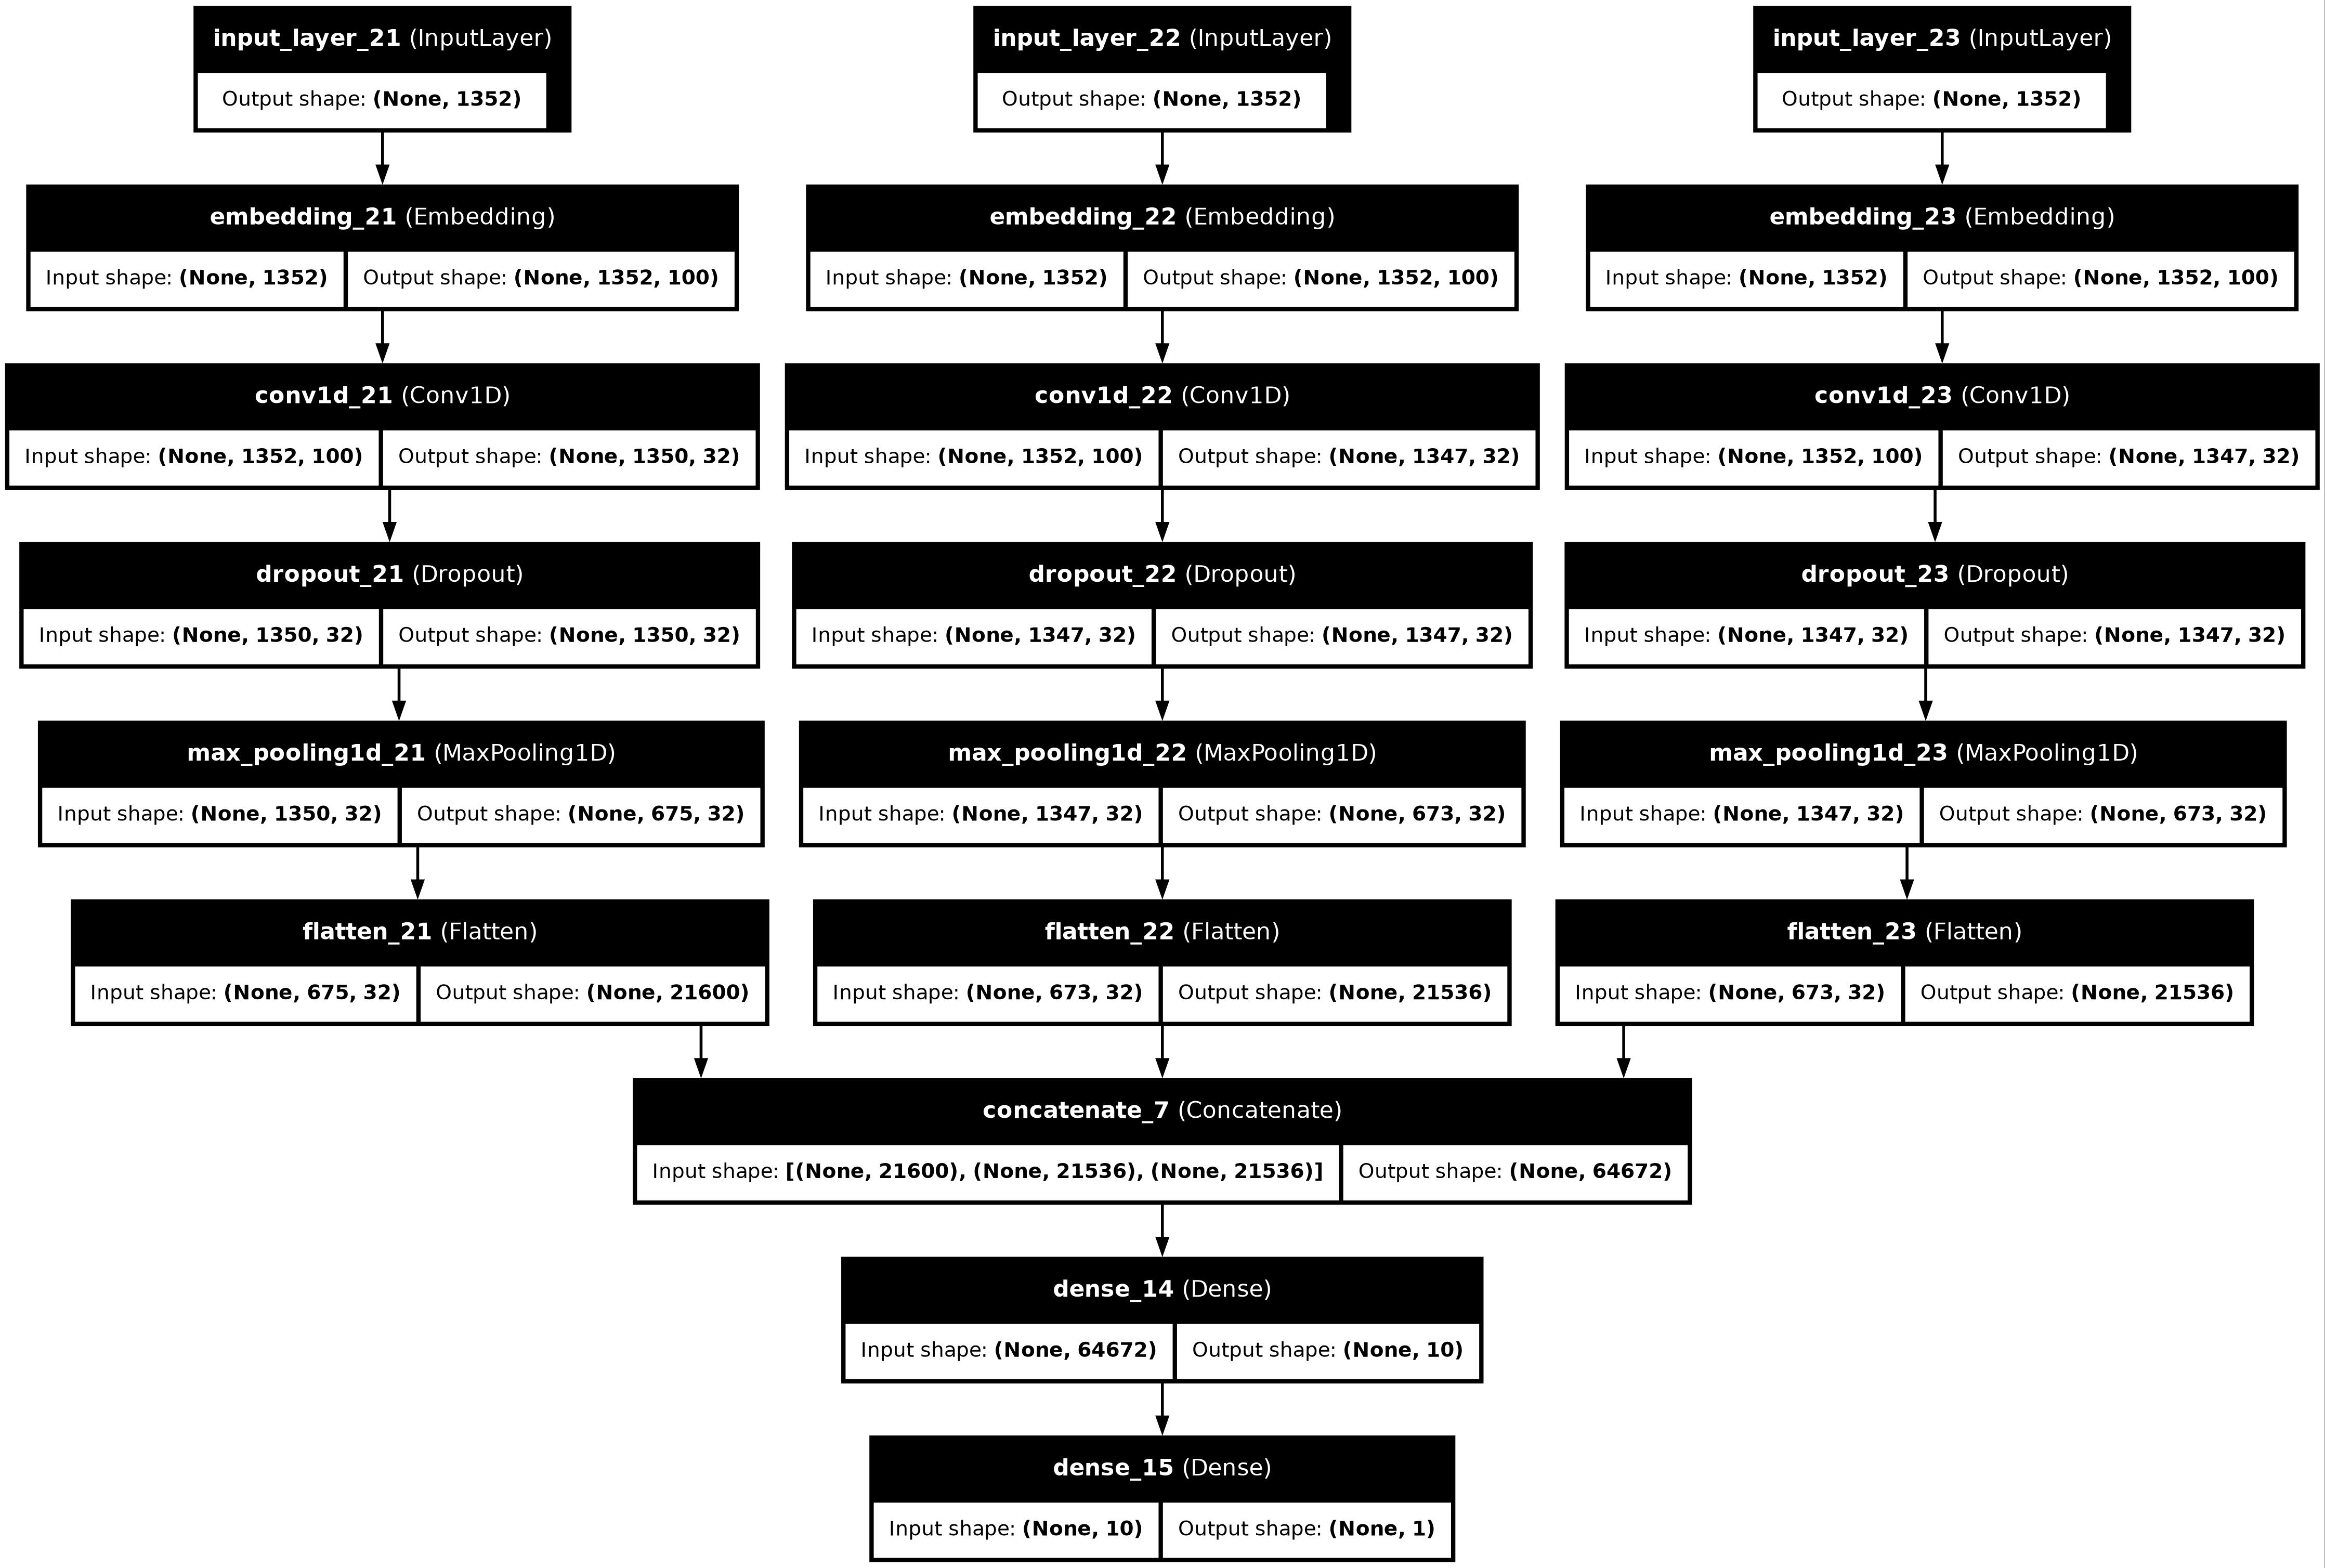

In [89]:
from tensorflow.keras.models import load_model

# Load the model 
my_model = load_model('cnn_model.h5')
test_x, test_y = load_dataset('review_polarity/txt_sentoken/test_x.pkl')

test_data = encode_text(tokenizer, test_x, length)
train_data = encode_text(tokenizer, train_x, length)

# evaluate the model on the test data
loss, accuracy = my_model.evaluate([train_data, train_data, train_data], array(train_y), verbose=    0)
print("Train Accuracy: %.4f" % (accuracy*100))


loss, accuracy = my_model.evaluate([test_data, test_data, test_data], array(test_y), verbose=0)
print("Test Accuracy: %.4f" % (accuracy*100))

plot_model(model, to_file='model.jpg', show_shapes=True, show_layer_names=True)

